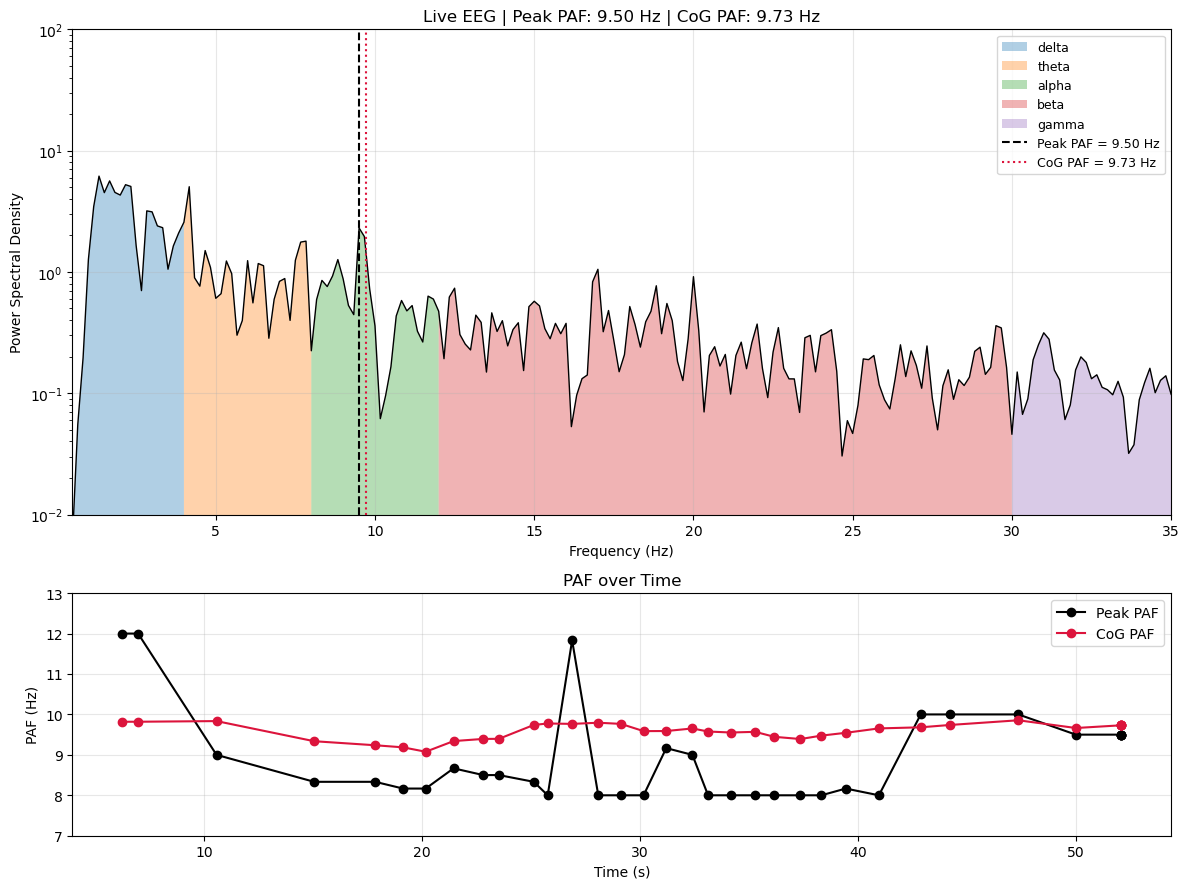

[INFO] 2026-04-25 17:51:57,934: [CLIENT]: Recording Finished
[INFO] 2026-04-25 17:51:57,936: [CLIENT]: Recording ID 1777132249202


In [1]:
import asyncio
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import display, clear_output
from scipy import signal
from scipy.signal import welch
from idun_guardian_sdk import GuardianClient

MY_API_TOKEN = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
fs = 250
WINDOW_SECONDS = 12
BUFFER_SIZE = fs * WINDOW_SECONDS
UPDATE_SECONDS = 0.5

ALPHA_BAND = (8, 12)
NPERSEG_SEC = WINDOW_SECONDS // 2

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}

sos_bp = signal.butter(N=4, Wn=[1, 40], btype="bandpass", fs=fs, output="sos")
b_notch, a_notch = signal.iirnotch(50, Q=30, fs=fs)

class LiveData:
    def __init__(self):
        self.timestamps = deque(maxlen=BUFFER_SIZE)
        self.ch1 = deque(maxlen=BUFFER_SIZE)
        self.is_running = True

live_buffer = LiveData()

paf_times = []
peak_pafs = []
cog_pafs = []
start_time = None

def handle_live_data(event):
    msg = getattr(event, "message", {})
    raw = msg.get("raw_eeg", []) if isinstance(msg, dict) else []
    for sample in raw:
        live_buffer.ch1.append(sample.get("ch1", 0.0))
        live_buffer.timestamps.append(sample.get("timestamp", 0.0))

def apply_window_filters(data_array):
    data_array = np.asarray(data_array, dtype=float)
    if len(data_array) < 50:
        return data_array
    filtered = signal.sosfiltfilt(sos_bp, data_array)
    filtered = signal.filtfilt(b_notch, a_notch, filtered)
    return filtered - np.mean(filtered)

def compute_paf(sig, fs, alpha_band=ALPHA_BAND, nperseg_sec=NPERSEG_SEC):
    sig = np.asarray(sig, dtype=float)
    nperseg = min(int(nperseg_sec * fs), len(sig))
    if nperseg < fs * 2:
        return np.nan, np.nan, None, None

    noverlap = nperseg // 2
    freqs, psd = welch(
        sig,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
        scaling="density"
    )

    alpha_mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    freqs_a = freqs[alpha_mask]
    psd_a = psd[alpha_mask]

    if len(freqs_a) == 0 or np.sum(psd_a) == 0:
        return np.nan, np.nan, freqs, psd

    peak_freq = freqs_a[np.argmax(psd_a)]
    cog_freq = np.sum(freqs_a * psd_a) / np.sum(psd_a)
    return peak_freq, cog_freq, freqs, psd

async def live_plot_task():
    global start_time

    nperseg_val = min(fs * NPERSEG_SEC, BUFFER_SIZE)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [2, 1]})
    plt.close(fig)

    while live_buffer.is_running:
        if len(live_buffer.ch1) >= nperseg_val:
            data = np.array(live_buffer.ch1, dtype=float)
            filtered_data = apply_window_filters(data)

            if len(filtered_data) >= nperseg_val:
                peak_paf, cog_paf, freqs, psd = compute_paf(filtered_data, fs)

                if freqs is not None:
                    current_t = 0.0
                    if len(live_buffer.timestamps) > 0:
                        if start_time is None:
                            start_time = live_buffer.timestamps[0]
                        current_t = live_buffer.timestamps[-1] - start_time

                    if not np.isnan(peak_paf):
                        paf_times.append(current_t)
                        peak_pafs.append(peak_paf)
                        cog_pafs.append(cog_paf)

                    ax1.clear()
                    ax1.semilogy(freqs, psd, color="black", linewidth=1)

                    for band, (f_low, f_high) in bands.items():
                        idx = (freqs >= f_low) & (freqs <= f_high)
                        if np.any(idx):
                            ax1.fill_between(freqs[idx], psd[idx], alpha=0.35, label=band)

                    if not np.isnan(peak_paf):
                        ax1.axvline(peak_paf, color="black", linestyle="--", linewidth=1.5,
                                    label=f"Peak PAF = {peak_paf:.2f} Hz")
                    if not np.isnan(cog_paf):
                        ax1.axvline(cog_paf, color="crimson", linestyle=":", linewidth=1.5,
                                    label=f"CoG PAF = {cog_paf:.2f} Hz")

                    ax1.set_xlabel("Frequency (Hz)")
                    ax1.set_ylabel("Power Spectral Density")
                    ax1.set_title(
                        f"Live EEG | Peak PAF: {peak_paf:.2f} Hz | CoG PAF: {cog_paf:.2f} Hz"
                    )
                    ax1.set_xlim(0.5, 35)
                    ax1.set_ylim(0.01, 100)
                    ax1.grid(True, alpha=0.3)
                    ax1.legend(loc="upper right", fontsize=9)

                    ax2.clear()
                    ax2.plot(paf_times, peak_pafs, marker="o", linewidth=1.5, label="Peak PAF", color="black")
                    ax2.plot(paf_times, cog_pafs, marker="o", linewidth=1.5, label="CoG PAF", color="crimson")
                    ax2.set_xlabel("Time (s)")
                    ax2.set_ylabel("PAF (Hz)")
                    ax2.set_title("PAF over Time")
                    ax2.set_ylim(ALPHA_BAND[0] - 1, ALPHA_BAND[1] + 1)
                    ax2.grid(True, alpha=0.3)
                    ax2.legend(loc="upper right")

                    fig.tight_layout()
                    clear_output(wait=True)
                    display(fig)

        await asyncio.sleep(UPDATE_SECONDS)

async def main():
    client = GuardianClient(api_token=MY_API_TOKEN)
    client.subscribe_live_insights(raw_eeg=True, handler=handle_live_data)

    plot_task = asyncio.create_task(live_plot_task())
    try:
        await client.start_recording(recording_timer=360, led_sleep=False, calc_latency=False)
    finally:
        live_buffer.is_running = False
        await plot_task

await main()